# **Introdução** 

### Contexto

O serviço de telefonia virtual CallMeMaybe está desenvolvendo uma nova funcionalidade que permitirá aos supervisores **identificar operadores menos eficientes**.

Os clientes da empresa são **organizações que precisam gerenciar grandes volumes de chamadas** — tanto recebidas quanto realizadas por diversos operadores.

De acordo com as regras de negócio, um operador é considerado **ineficiente** se:

- Possui **muitas chamadas recebidas perdidas** (internas ou externas);
- Apresenta **tempo de espera prolongado** nas chamadas recebidas;
- E, no caso de operadores responsáveis por chamadas de saída, realiza **poucas chamadas ativas**.

### Dados

O dataset compactado **`telecom_dataset_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID da conta do cliente
- **`date`**: data em que as estatísticas foram coletadas
- **`direction`**: “direção” da chamada (`out` para chamadas **saídas**, `in` para chamadas **entrantes**)
- **`internal`**: indica se a chamada foi **interna** (entre operadores de um mesmo cliente)
- **`operator_id`**: identificador do operador
- **`is_missed_call`**: indica se foi uma **chamada perdida**
- **`calls_count`**: número de chamadas
- **`call_duration`**: duração da chamada (sem incluir o tempo de espera)
- **`total_call_duration`**: duração total da chamada (incluindo o tempo de espera)
O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

O conjunto de dados **`telecom_clients_us.csv`** contém as seguintes colunas:

- **`user_id`**: ID do cliente
- **`tariff_plan`**: plano tarifário atual do cliente
- **`date_start`**: data de registro do cliente

### Objetivo 

O objetivo desta análise será identificar operadores com padrões abaixo do esperado com base em seu desempenho, sob a perspectiva de três métricas principais: chamadas perdidas, tempo de espera, e volume de chamadas outbound.  

# **Setup e Dados**

## Ambiente

### Importação bibliotecas

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as mp
from scipy import stats as st

### Configurações Globais

In [103]:
# reprodutibilidade — seed único
RANDOM_STATE = 42

# exibição de dados
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

### Carregamento de dados

In [104]:
# leitura arquivo CSV
telecom_raw = pd.read_csv('../data/raw/telecom_dataset_new.csv')

In [105]:
# leitura arquivo CSV
clients_raw = pd.read_csv('../data/raw/telecom_clients.csv')

## Pré Processamento 

### Primeiras impressões

#### *Telecom*

In [106]:
# primeira visualização
telecom_raw.head(10)

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
9,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62


In [107]:
# descoberta informações sobre o dataframe
telecom_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


O dataset *telecom* possui a nomenclatura de suas colunas dentro do padrão snake_case. 

Encontram-se valores ausentes nas colunas `internal` e `operator_id`. 

Seria mais adequado mudança no tipo de dado em colunas como `date` para `datetime` visando operações com datas, e `operator_id` e `user_id` para `str` por serem identificadores e não propriamente um valor numérico para cálculos.

#### *Clients*

In [108]:
# primeira visualização
clients_raw.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [109]:
# descoberta informações sobre o datafrane  
clients_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


O dataset *clients* possui a nomenclatura de suas colunas dentro do padrão snake_case.

Não encontram-se valores ausentes.

Seria mais adequado mudança no tipo de dado na coluna `date_start` para `datetime`, visando operações com datas e `user_id` para `str` visando consitência.

### Tratamento de valores duplicados

In [110]:
# criação de cópias
telecom = telecom_raw.copy()
clients = clients_raw.copy()

In [111]:
# descoberta quantidade de valores duplicados
print(f'Número de registros duplicados no dataframe Telecom: {telecom.duplicated().sum()}')
print(f'Número de registros duplicados no dataframe Clients: {clients.duplicated().sum()}')

Número de registros duplicados no dataframe Telecom: 4900
Número de registros duplicados no dataframe Clients: 0


In [112]:
# visualização de registros duplicados
telecom[telecom.duplicated()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.00,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.00,False,11,1413,1473
...,...,...,...,...,...,...,...,...,...
53869,168601,2019-11-25 00:00:00+03:00,in,False,952914.00,False,7,1229,1282
53874,168601,2019-11-26 00:00:00+03:00,in,False,952914.00,False,4,539,562
53875,168601,2019-11-26 00:00:00+03:00,in,False,NaN,True,3,0,35
53885,168603,2019-11-20 00:00:00+03:00,out,False,959118.00,True,3,0,89


In [113]:
# visualização amostra registros de um operador aleatório
telecom_raw[telecom_raw['operator_id'] == 880020.00]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
5,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,False,2,3,29
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.00,True,8,0,50
11,166377,2019-08-06 00:00:00+03:00,out,False,880020.00,True,5,0,70
13,166377,2019-08-06 00:00:00+03:00,out,False,880020.00,False,5,800,819
16,166377,2019-08-07 00:00:00+03:00,out,False,880020.00,False,2,232,240
76,166377,2019-08-22 00:00:00+03:00,in,False,880020.00,False,1,33,49
124,166377,2019-09-02 00:00:00+03:00,out,True,880020.00,True,2,0,0


In [114]:
# remoção dados duplicados
telecom = telecom.drop_duplicates().reset_index(drop=True)

**Decisão Metodológica**: remoção de duplicatas.

4.900 linhas duplicadas identificadas (~9% do dataset original de 53.902 linhas). 

Critério: linha completamente idêntica em todas as 9 colunas. 

Dataset após limpeza: 49.002 linhas.

Cada linha representa um agregado por combinação única de (`user_id`, `date`, `direction`, `internal`, `operator_id`, `is_missed_call`). 

Dentro desta estrutura, dois registos com valores idênticos em todas as colunas são impossíveis como dado legítimo — confirmado na inspeção do operador 880020 (índices 6 e 8: linha idêntica em todas as 9 colunas).

### Tratamento de valores nulos

In [115]:
# descoberta quantidade registros ausentes dataset telecom
telecom.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                110
operator_id            7456
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Valores nulos em duas colunas: `internal` e `operator_id`.

In [116]:
# descoberta quantidade registros ausentes dataset clients
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [117]:
# visualização de registros ausentes na coluna internal
telecom[telecom['internal'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
917,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
996,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1705,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1761,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.00,False,1,2,9
5645,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.00,False,1,393,423
...,...,...,...,...,...,...,...,...,...
47702,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
47819,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
47844,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
48837,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


In [118]:
# visualização de registros ausentes na coluna operator_id
telecom[telecom['operator_id'].isnull()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
7,166377,2019-08-05 00:00:00+03:00,in,False,NaN,True,6,0,35
8,166377,2019-08-06 00:00:00+03:00,in,False,NaN,True,4,0,62
16,166377,2019-08-07 00:00:00+03:00,in,False,NaN,True,2,0,24
26,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
...,...,...,...,...,...,...,...,...,...
48978,168601,2019-11-27 00:00:00+03:00,in,False,NaN,True,2,0,39
48982,168601,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,19
48990,168603,2019-11-28 00:00:00+03:00,in,False,NaN,True,1,0,30
48994,168606,2019-11-08 00:00:00+03:00,in,False,NaN,True,6,0,121


In [119]:
# contagem de chamadas perdidas dentre os operadores não identificados
telecom[telecom['operator_id'].isnull()]['is_missed_call'].value_counts()

is_missed_call
True     7343
False     113
Name: count, dtype: int64

A maioria esmagadora (~98,5%) de valores nulos na coluna `operator_id` são referentes a chamadas perdidas. 

In [120]:
# contagem de chamadas inbound dentre os operadores não identificados
telecom[telecom['operator_id'].isnull()]['direction'].value_counts()

direction
in     7270
out     186
Name: count, dtype: int64

A maioria esmagadora (~97,5%) de valores nulos na coluna `operator_id` são referentes a chamadas inbound.

In [121]:
telecom[telecom['is_missed_call'] == True].shape[0]

21453

Um volume infímo de 110 chamadas (~0,2%) não possuem identificação se foram entre operadores de um mesmo cliente.

Cerca ~35% do total de chamadas perdidas do dataset não possuem operador identificado.

Padrão consistente com chamadas que chegaram ao sistema mas nunca foram atribuídas a um operador.

**DECISÃO METODOLÓGICA**:
manutenção de registros de chamada sem operador atrelado e identificação se foram entre operadores de um mesmo cliente.

Das 7.456 linhas com `operator_id` nulo:
- 7.270 (~97.5%) são chamadas inbound
- 7.343 (~98.5%) têm `is_missed_call = True`
- Representam 34.2% do total de chamadas perdidas do dataset (7.343 / 21.453)

Interpretação: chamadas que chegaram ao sistema mas nunca foram atribuídas a um operador — não existe operador a avaliar individualmente. Estas linhas são mantidas no dataset completo para preservar a taxa real de chamadas perdidas ao nível da empresa, mas são excluídas automaticamente nas análises por operador por ausência de `operator_id`.

### Alterações de tipos de dados

In [122]:
# conversões de indicadores para str
telecom['user_id']= telecom['user_id'].astype('str')
telecom['operator_id'] = telecom['operator_id'].astype(str).replace('nan', pd.NA)
clients['user_id'] = clients['user_id'].astype('str')

In [123]:
# conversões para datetime
telecom['date'] = pd.to_datetime(telecom['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

### Engenharia de features

In [124]:
# criação coluna tempo de espera
telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']
print(f"Registros com tempo de espera negativo: {(telecom['waiting_time'] < 0).sum()}")

Registros com tempo de espera negativo: 0


In [125]:
# criação coluna mês
telecom['month'] = telecom['date'].dt.month 

In [126]:
# criação coluna semana
telecom['week'] = telecom['date'].dt.isocalendar().week 

In [127]:
# criação dataframe agregado entre duas tablas base
telecom_merged = telecom.merge(
    clients, 
    on='user_id',
    how='left'
)

In [128]:
# filtro para análise sem dados nulos
telecom_ops = telecom_merged[telecom_merged['operator_id'].notna()].copy()
telecom_ops = telecom_ops[telecom_ops['internal'].notna()].copy()

# **EDA**

### Investigação variáveis chave

#### Tempo de espera

In [129]:
# descoberta características variável chave tempo de espera
telecom_ops['waiting_time'].describe()

count   41491.00
mean      312.21
std      1176.10
min         0.00
25%        19.00
50%        60.00
75%       219.00
max     46474.00
Name: waiting_time, dtype: float64

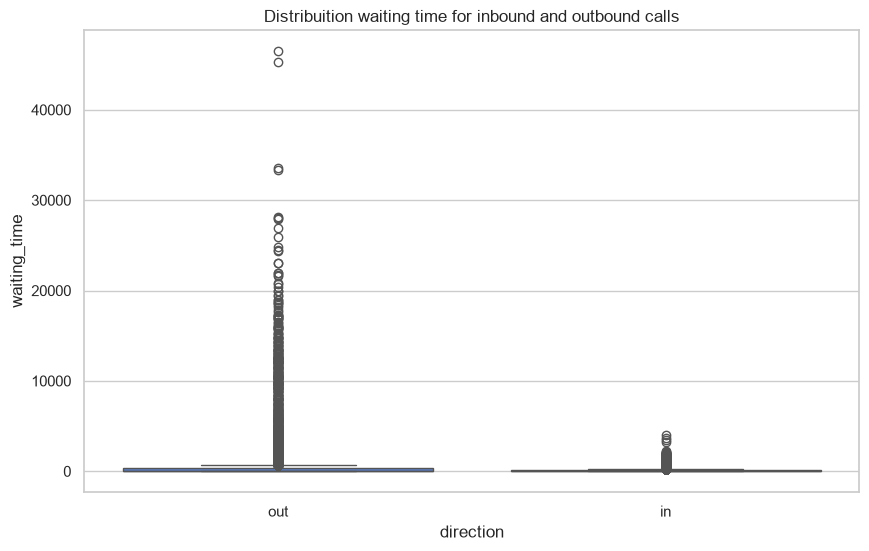

In [130]:
# criação boxplot para visualização variável contínua
sns.boxplot(
    data=telecom_ops, 
    x='direction', 
    y='waiting_time'
)
plt.title('Distribuition waiting time for inbound and outbound calls')
plt.show()

In [131]:
# descoberta características tempo de espera para chamadas inbound
telecom_ops[telecom_ops['direction'] == 'in']['waiting_time'].describe()

count   12678.00
mean       97.20
std       185.59
min         0.00
25%        17.00
50%        38.00
75%        97.00
max      3998.00
Name: waiting_time, dtype: float64

A distribuição é fortemente assimétrica à direita na distriuição da variável alvo `waiting_time`, tanto em chamadas inbound e outbound. 

A maioria dos registros tem tempos de espera relativamente curtos, enquanto uma minoria de registros apresenta tempos de espera extremamente longos, gerando valores atípicos na cauda superior da distribuição.

A menor parte das ocorrências de outliers está dentro da categoria inbound.

#### Contagem de chamadas

In [132]:
# descoberta características variável chave contagem de chamadas
telecom_ops['calls_count'].describe()

count   41491.00
mean       16.92
std        59.79
min         1.00
25%         1.00
50%         4.00
75%        14.00
max      4817.00
Name: calls_count, dtype: float64

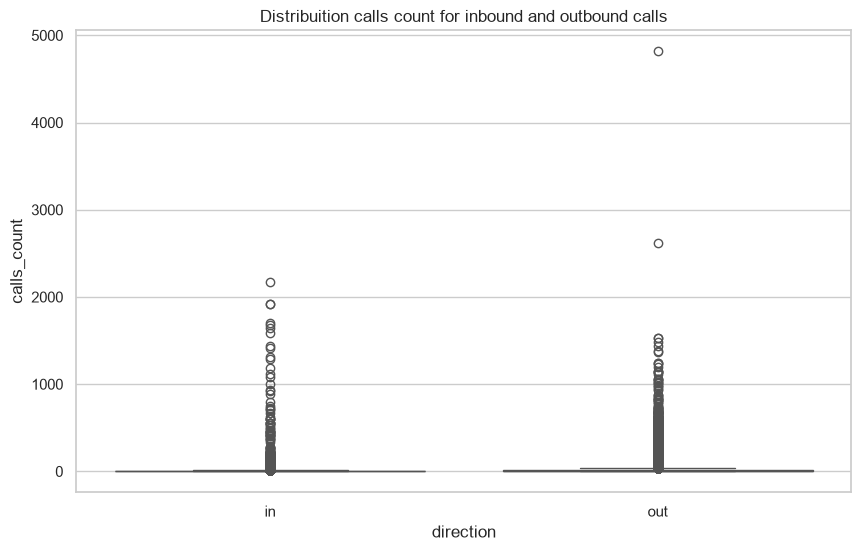

In [133]:
# criação boxplot para variável contínua
sns.boxplot(
    data=telecom, 
    x='direction', 
    y='calls_count'
)
plt.title('Distribuition calls count for inbound and outbound calls')
plt.show()

In [134]:
# descoberta características contagem de chamadas para outbound
telecom_ops[telecom_ops['direction'] == 'out']['calls_count'].describe()

count   28813.00
mean       21.11
std        70.64
min         1.00
25%         2.00
50%         5.00
75%        18.00
max      4817.00
Name: calls_count, dtype: float64

A distribuição é fortemente assimétrica à direita na distriuição da variável alvo `calls_count`, tanto em chamadas inbound e outbound. 

A maioria das observações envolve apenas algumas chamadas, enquanto um número pequeno de registos apresenta volumes de chamadas excepcionalmente elevados, gerando numerosos valores atípicos na cauda superior da distribuição.

Dentro das chamada outbound valor máximo atinge 4817 chamadas, apesar de a mediana ser de apenas 5.

#### Chamadas perdidas

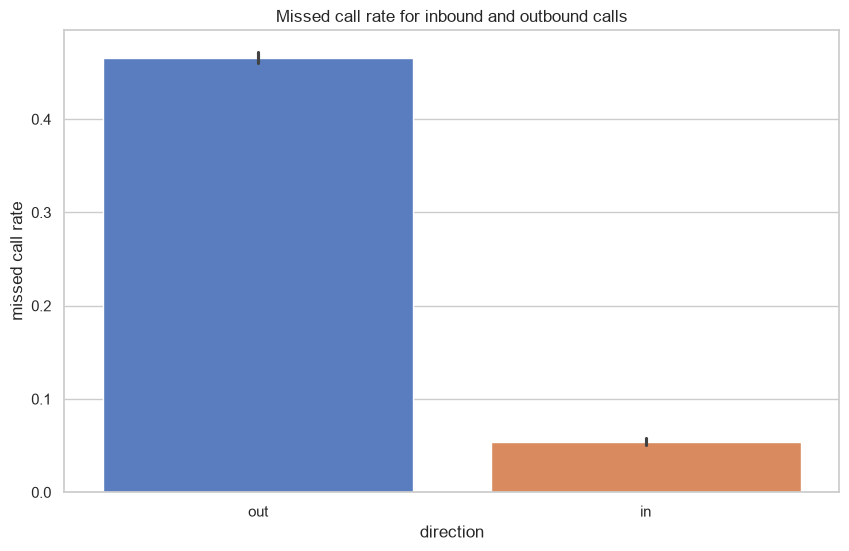

In [258]:
# criação gráfico de barras para variável categórica
sns.barplot(
    data=telecom_ops,
    x='direction',
    y='is_missed_call',
    hue='direction'
)
plt.title('Missed call rate for inbound and outbound calls')
plt.ylabel('missed call rate')
plt.show()

As chamadas inbound apresentam um desequilíbrio acentuado no que diz respeito à variável-alvo `is_missed_call`. 

A maioria das chamadas inbound foi atendida, enquanto as chamadas perdidas representam apenas uma pequena fração das observações (~5%). 

Em contrapartida, as chamadas outbound apresentam uma distribuição muito mais equilibrada entre chamadas atendidas e chamadas perdidas (~45%).

### Volumes temporais

In [151]:
telecom_ops['month'].unique()

array([ 8,  9, 10, 11], dtype=int32)

O período de registros do dataset cobre os meses de Agosto, Setembro, Outubro e Novembro.

#### Volume semanal de chamadas

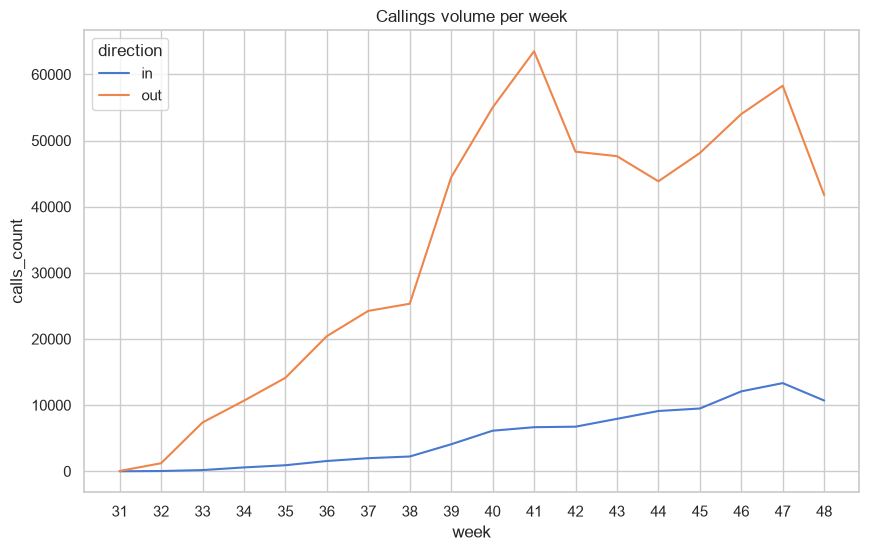

In [266]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=telecom_ops.groupby(['week', 'direction'])['calls_count'].sum().reset_index(), x='week', y='calls_count', hue='direction')
plt.title('Callings volume per week')
plt.xticks(telecom['week'].unique())
plt.show()

É notável o crescimento do volume de chamadas registrados durante o período de observação.  

Enquanto as chamadas outbound tem crescimento acelerado, as chamadas inbound seguiu um ritmo diferente.

#### Volume semanal de operadores

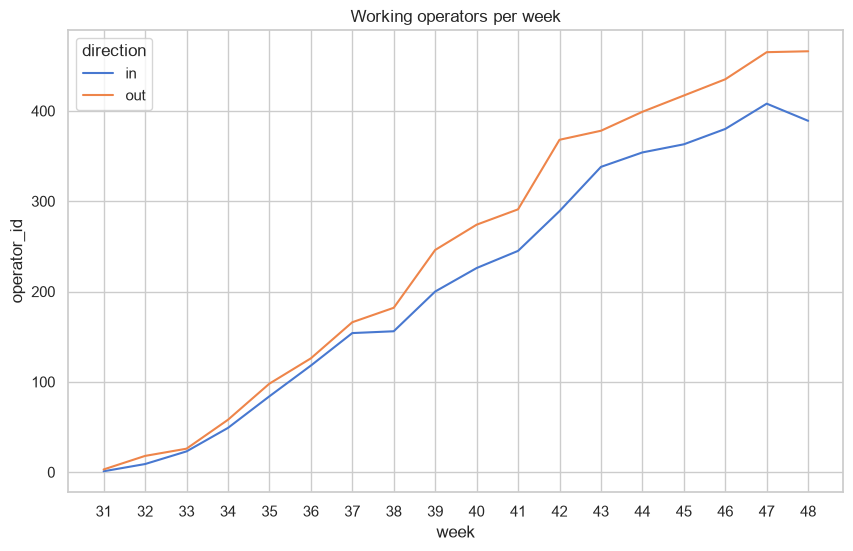

In [267]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=telecom_ops.groupby(['week', 'direction'])['operator_id'].nunique().reset_index(), x='week', y='operator_id', hue='direction')
plt.title('Working operators per week')
plt.xticks(telecom_ops['week'].unique())
plt.show()

É notável o crescimento do volume de chamadas registrados durante o período de observação.  

Contudo, diferente do que foi observado no volume de chamadas, o número de operadores de outbound e inbound cresceram numa proporção similar.

#### Volume semanal de chamadas inbound perdidas

In [260]:
# criação agregado inbound
weekly_inbound_ratio = (
    telecom_ops[
        telecom_ops['direction'] == 'in'
    ]
    .groupby('week')['calls_count']
    .sum()
    .reset_index()
)

In [261]:
# contagem de chamadas inbound perdidas
missed_inbound_calls = (
    telecom_ops[
        (telecom_ops['direction'] == 'in') &
        (telecom_ops['is_missed_call'] == True)
    ]
    .groupby('week', as_index=False)['calls_count']
    .sum()
    .rename(columns={'calls_count': 'missed_calls'})
)

In [262]:
# união resultado ao agregado
weekly_inbound_ratio = weekly_inbound_ratio.merge(
    missed_inbound_calls,
    on='week',
    how='left'
)

In [263]:
# criação coluna ratio 
weekly_inbound_ratio['ratio'] = weekly_inbound_ratio['missed_calls'] / weekly_inbound_ratio['calls_count'] 

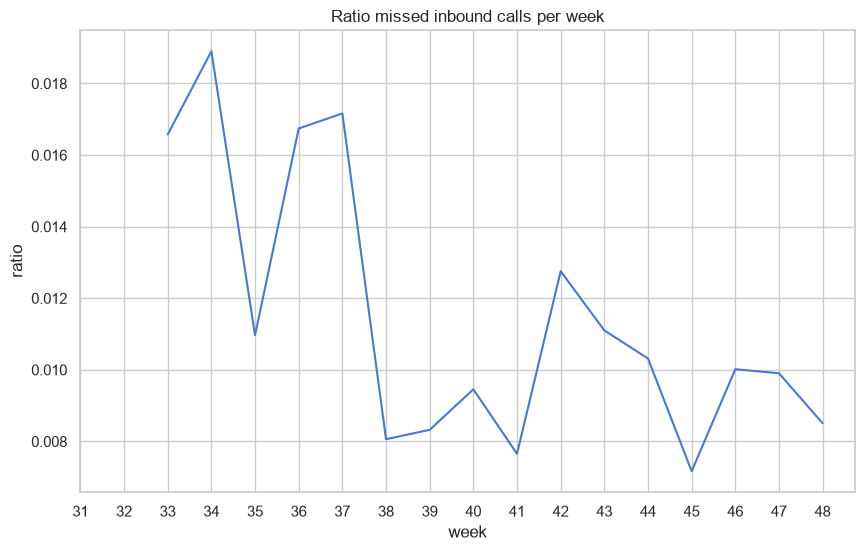

In [264]:
# criação gráfico de linhas para visualização temporal
sns.lineplot(data=weekly_inbound_ratio, x='week', y='ratio')
plt.title('Ratio missed inbound calls per week')
plt.xticks(weekly_inbound_ratio['week'].unique())
plt.show()

A taxa de chamadas perdidas apresenta comportamento com tendência de queda com o avançar das semanas (de ~0.02% para ~0.01%) apesar do aumento no volume de chamadas.

### a